In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "/ofo-share/repos/david/tree-detection-parameterization/data/scores.csv"

DATASETS_TO_EXCLUDE = set(
    [
        "0128_000018_000016",
        "0137_000208_000210",
        "0157_000204_000205",
        "0162_000211_000220",
        "0163_000211_000220",
        "0167_000319_000318",
        "0172_001270_001271",
        "0174_001270_001271",
        "0191_001211_001210",
        "0194_001213_001212",
        "0208_000112_000310",
        "0211_000112_000310",
    ]
)

data = pd.read_csv(FILE)
# Temporary: parse sigma, b, c from param_combo column (format: sigma_{sigma}__b_{b}_c_{c})
data["sigma"] = data.param_combo.str.extract(r"sigma_([\d.]+)__").astype(float)
data["b"] = data.param_combo.str.extract(r"_b_([\d.]+)_c_").astype(float)
data["c"] = data.param_combo.str.extract(r"_c_([\d.]+)$").astype(float)

In [52]:
data = data[~data.dataset.isin(DATASETS_TO_EXCLUDE)]

In [53]:
data_without_dataset = data.drop(columns="dataset")
mean_results = data_without_dataset.groupby("param_combo").mean()
mean_results = mean_results.sort_values("F1")

mean_results[["sigma", "b", "c", "F1"]].tail(10)

,sigma,b,c,F1
param_combo,,,,
sigma_0.6666666666666666__b_0.02_c_0.2,0.666667,0.02,0.2,0.722076
sigma_0.5__b_0.02_c_0.4,0.500000,0.02,0.4,0.722204
sigma_0.6666666666666666__b_0.03_c_0.0,0.666667,0.03,0.0,0.722549
sigma_0.5__b_0.03_c_0.2,0.500000,0.03,0.2,0.722730
sigma_0.5__b_0.02_c_0.2,0.500000,0.02,0.2,0.722915
sigma_0.5__b_0.04_c_0.0,0.500000,0.04,0.0,0.723249
sigma_0.5__b_0.03_c_0.0,0.500000,0.03,0.0,0.723357
sigma_0.5__b_0.02_c_0.0,0.500000,0.02,0.0,0.733306
sigma_0.8333333333333333__b_0.02_c_0.0,0.833333,0.02,0.0,0.738875


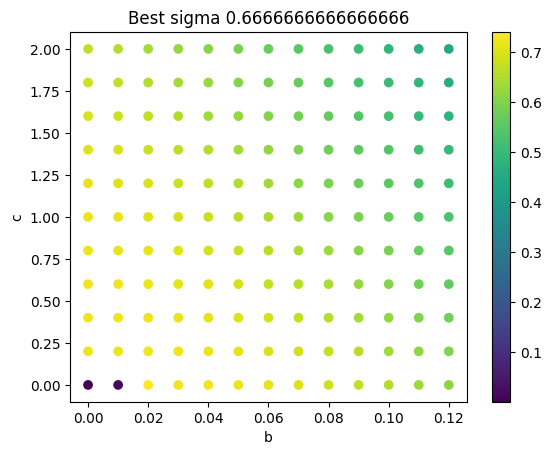

,sigma,b,c,F1,precision,recall,n_core_field,n_core_drone,n_field_matched,n_drone_matched
param_combo,,,,,,,,,,
sigma_0.6666666666666666__b_0.0_c_0.0,0.666667,0.00,0.0,0.001290,0.000645,0.956714,128.223022,214703.899281,121.985612,115.158273
sigma_0.6666666666666666__b_0.01_c_0.0,0.666667,0.01,0.0,0.017010,0.008671,0.854750,128.223022,14206.194245,107.086331,100.014388
sigma_0.6666666666666666__b_0.12_c_2.0,0.666667,0.12,2.0,0.447487,0.889745,0.314559,128.223022,42.237410,38.525180,37.381295
sigma_0.6666666666666666__b_0.12_c_1.8,0.666667,0.12,1.8,0.463160,0.890034,0.329575,128.223022,44.402878,40.438849,39.230216
sigma_0.6666666666666666__b_0.11_c_2.0,0.666667,0.11,2.0,0.466110,0.890858,0.331839,128.223022,44.863309,40.798561,39.676259
...,...,...,...,...,...,...,...,...,...,...
sigma_0.6666666666666666__b_0.01_c_0.2,0.666667,0.01,0.2,0.721186,0.810085,0.666360,128.223022,102.726619,79.726619,78.287770
sigma_0.6666666666666666__b_0.01_c_0.4,0.666667,0.01,0.4,0.721786,0.820757,0.660190,128.223022,99.812950,78.848921,77.453237
sigma_0.6666666666666666__b_0.02_c_0.2,0.666667,0.02,0.2,0.722076,0.823098,0.659175,128.223022,98.978417,78.697842,77.287770


In [54]:
best_params = mean_results.index[-1]
best_sigma = best_params.split("_")[1]

mean_results_blur = mean_results[mean_results.sigma == float(best_sigma)]

plt.scatter(mean_results_blur["b"], mean_results_blur["c"], c=mean_results_blur["F1"])
plt.colorbar()
plt.title(f"Best sigma {best_sigma}")
plt.xlabel("b")
plt.ylabel("c")
plt.show()
display(mean_results_blur)

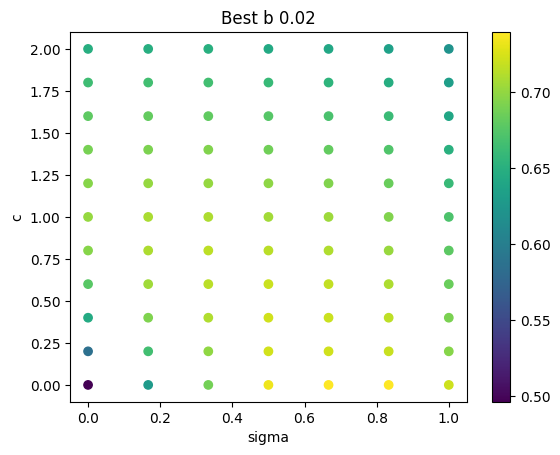

,sigma,b,c,F1,precision,recall,n_core_field,n_core_drone,n_field_matched,n_drone_matched
param_combo,,,,,,,,,,
sigma_0.0__b_0.02_c_0.0,0.000000,0.02,0.0,0.496287,0.372732,0.844281,128.223022,309.762590,101.690647,96.374101
sigma_0.0__b_0.02_c_0.2,0.000000,0.02,0.2,0.584724,0.489247,0.787899,128.223022,221.187050,94.302158,93.115108
sigma_1.0__b_0.02_c_2.0,1.000000,0.02,2.0,0.621316,0.893904,0.493612,128.223022,67.129496,59.899281,58.482014
sigma_0.16666666666666666__b_0.02_c_0.0,0.166667,0.02,0.0,0.627371,0.540711,0.793592,128.223022,190.309353,96.057554,90.352518
sigma_1.0__b_0.02_c_1.8,1.000000,0.02,1.8,0.631264,0.891180,0.506052,128.223022,69.064748,61.438849,59.942446
...,...,...,...,...,...,...,...,...,...,...
sigma_0.5__b_0.02_c_0.4,0.500000,0.02,0.4,0.722204,0.801079,0.670513,128.223022,103.201439,79.863309,78.618705
sigma_0.5__b_0.02_c_0.2,0.500000,0.02,0.2,0.722915,0.786114,0.682284,128.223022,107.338129,81.294964,80.000000
sigma_0.5__b_0.02_c_0.0,0.500000,0.02,0.0,0.733306,0.760766,0.722625,128.223022,111.985612,86.690647,80.374101


In [55]:
best_params = mean_results.index[-1]
best_b = best_params.split("_")[-3]

mean_results_blur = mean_results[mean_results.b == float(best_b)]

plt.scatter(mean_results_blur["sigma"], mean_results_blur["c"], c=mean_results_blur["F1"])
plt.colorbar()
plt.title(f"Best b {best_b}")
plt.xlabel("sigma")
plt.ylabel("c")
plt.show()
display(mean_results_blur)

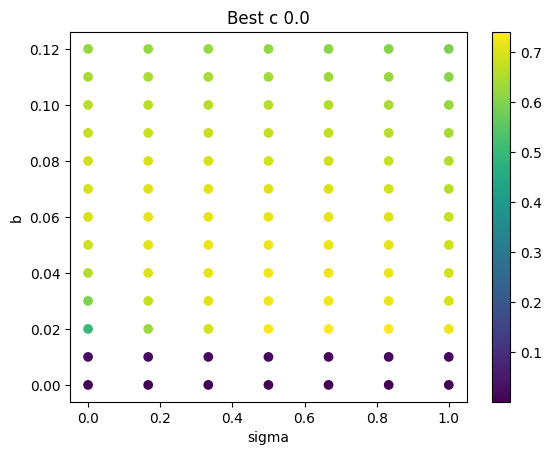

,sigma,b,c,F1,precision,recall,n_core_field,n_core_drone,n_field_matched,n_drone_matched
param_combo,,,,,,,,,,
sigma_1.0__b_0.0_c_0.0,1.000000,0.00,0.0,0.001274,0.000637,0.948505,128.223022,215526.208633,121.208633,113.510791
sigma_0.8333333333333333__b_0.0_c_0.0,0.833333,0.00,0.0,0.001286,0.000643,0.954692,128.223022,214946.971223,121.769784,114.633094
sigma_0.6666666666666666__b_0.0_c_0.0,0.666667,0.00,0.0,0.001290,0.000645,0.956714,128.223022,214703.899281,121.985612,115.158273
sigma_0.5__b_0.0_c_0.0,0.500000,0.00,0.0,0.001301,0.000651,0.958392,128.223022,214535.230216,122.208633,115.669065
sigma_0.3333333333333333__b_0.0_c_0.0,0.333333,0.00,0.0,0.001305,0.000653,0.961430,128.223022,214447.856115,122.647482,116.546763
...,...,...,...,...,...,...,...,...,...,...
sigma_0.5__b_0.04_c_0.0,0.500000,0.04,0.0,0.723249,0.806611,0.668178,128.223022,101.294964,79.482014,78.179856
sigma_0.5__b_0.03_c_0.0,0.500000,0.03,0.0,0.723357,0.789202,0.681157,128.223022,106.388489,81.201439,79.870504
sigma_0.5__b_0.02_c_0.0,0.500000,0.02,0.0,0.733306,0.760766,0.722625,128.223022,111.985612,86.690647,80.374101


In [56]:
best_params = mean_results.index[-1]
best_c = best_params.split("_")[-1]

mean_results_blur = mean_results[mean_results.c == float(best_c)]

plt.scatter(mean_results_blur["sigma"], mean_results_blur["b"], c=mean_results_blur["F1"])
plt.colorbar()
plt.title(f"Best c {best_c}")
plt.xlabel("sigma")
plt.ylabel("b")
plt.show()
display(mean_results_blur)

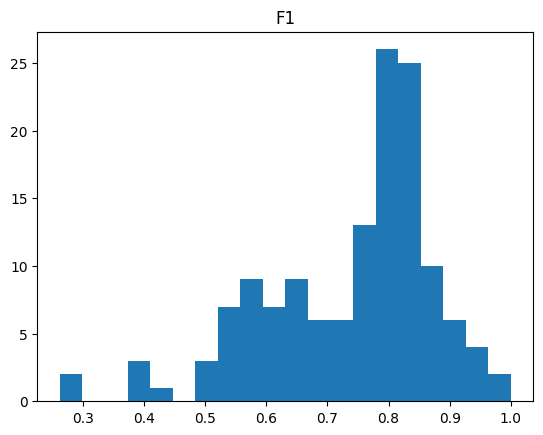

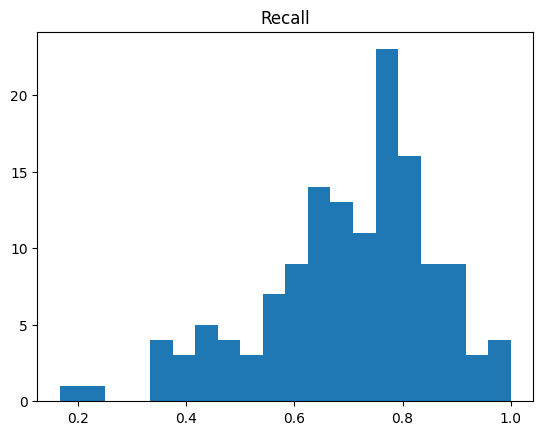

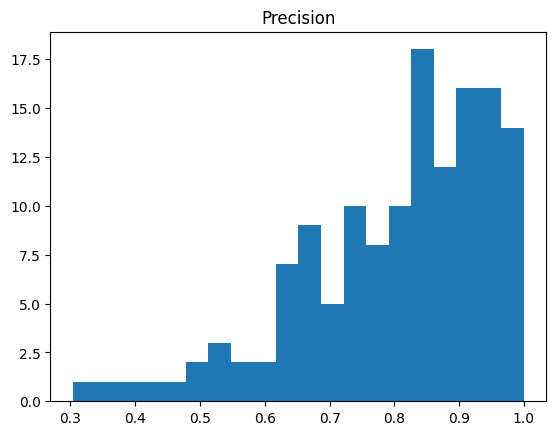

In [57]:
subset_data = data.query("param_combo == 'sigma_0.6666666666666666__b_0.02_c_0.0'")
plt.hist(subset_data["F1"], bins=20)
plt.title(f"F1")
plt.show()
plt.close()

plt.hist(subset_data["recall"], bins=20)
plt.title(f"Recall")
plt.show()
plt.close()

plt.hist(subset_data["precision"], bins=20)
plt.title(f"Precision")
plt.show()
plt.close()